# Tech Challenge - Fase 1: Visão Computacional (Diagnóstico de Ultrassom)
Este notebook aborda o diagnóstico automatizado de lesões mamárias a partir de imagens de ultrassom (Dataset BUSI) utilizando **Redes Neurais Convolucionais (CNN)** e **Transfer Learning** com a arquitetura **MobileNetV2**. O fluxo inclui pré-processamento, aumento de dados (Data Augmentation), treinamento com técnicas para evitar sobreajuste, avaliação de desempenho e **Explicabilidade Visual com Grad-CAM**.

In [1]:
# ==========================================
# 1. INSTALAÇÃO DE DEPENDÊNCIAS E SETUP
# ==========================================
!pip install -q kagglehub opencv-python

import os
import glob
import random
import warnings
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

# --- CONFIGURAÇÃO DE REPRODUTIBILIDADE ---
# Definimos uma 'semente' (SEED) fixa para que o computador gere os mesmos números aleatórios em todas as execuções.
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

print("Versão do TensorFlow:", tf.__version__)
print("Placa de Vídeo (GPU) Detectada:", tf.config.list_physical_devices('GPU'))

Versão do TensorFlow: 2.20.0
Placa de Vídeo (GPU) Detectada: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


> 📌 **Resumo Explicativo (Step 1: Preparação do Ambiente)**
> * **O que foi feito:** Instalamos e carregamos as ferramentas (bibliotecas) necessárias. O **TensorFlow/Keras** é o motor para criar a Inteligência Artificial, o **OpenCV (`cv2`)** serve para manipular imagens e o **Matplotlib** para gerar os gráficos.
> * **Por que isso é importante?** Em Ciência de Dados, o controle de reprodutibilidade (`SEED = 42`) garante que qualquer cientista ou médico que rodar este código no futuro obterá exatamente os mesmos resultados de acurácia.
> * **Conclusão:** O ambiente de desenvolvimento está configurado e pronto para utilizar a placa de vídeo (GPU) do servidor.

In [2]:
# ==========================================
# 2. DOWNLOAD DO DATASET (BUSI)
# ==========================================
import kagglehub

# O banco de dados BUSI (Breast Ultrasound Images) é composto por exames de ultrassom clínicos.
path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset")
print("Caminho do Dataset baixado:", path)

dataset_dir = path
if os.path.exists(os.path.join(path, "Dataset_BUSI_AN")):
    dataset_dir = os.path.join(path, "Dataset_BUSI_AN")
busi_path = os.path.join(dataset_dir, "Dataset_BUSI_with_GT")

Using Colab cache for faster access to the 'breast-ultrasound-images-dataset' dataset.
Caminho do Dataset baixado: /kaggle/input/breast-ultrasound-images-dataset


> 📌 **Resumo Explicativo (Step 2: Obtenção das Imagens Médicas)**
> * **O que foi feito:** Baixamos o banco de dados oficial **BUSI** diretamente do repositório Kaggle via código em tempo de execução.
> * **O que este banco contém?** Ele reúne exames reais de ultrassom de mama categorizados em três diagnósticos: **Benigno** (tumores sem risco imediato), **Maligno** (câncer) e **Normal** (tecido saudável sem lesão).
> * **Conclusão:** As imagens brutas foram baixadas e o caminho de seus arquivos está salvo na memória para a próxima fase.

Total de exames de ultrassom localizados: 780
Imagens separadas para Treinamento: 624
Imagens separadas para Validação/Teste: 156

Distribuição por Diagnóstico no Treino:
label
benign       350
malignant    168
normal       106
Name: count, dtype: int64


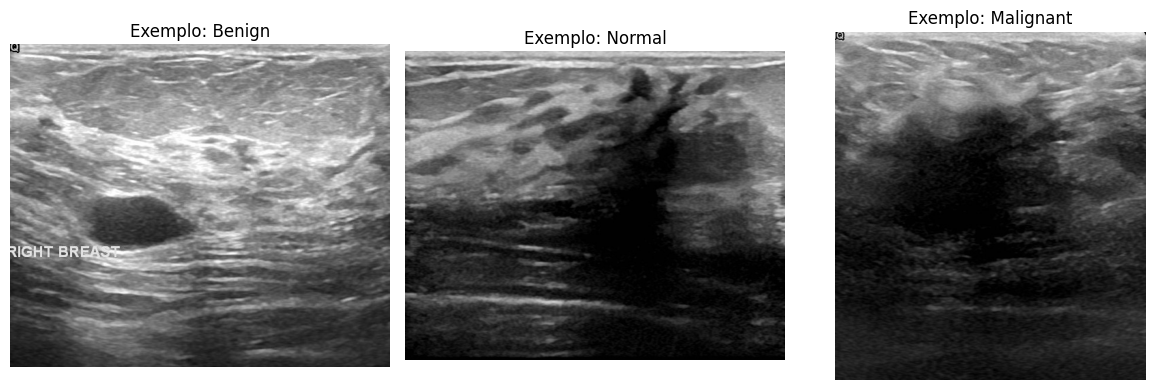

In [3]:
# ==========================================
# 3. ORGANIZAÇÃO DOS DADOS E DIVISÃO (TREINO/VALIDAÇÃO)
# ==========================================

all_images = glob.glob(os.path.join(busi_path, '*/*.png'))
data_list = []

# Filtragem para selecionar apenas exames brutos (descartando arquivos de máscaras de segmentação com o sufixo '_mask')
for img_path in all_images:
    if 'mask' not in img_path.lower():
        label = os.path.basename(os.path.dirname(img_path))
        data_list.append({'filepath': img_path, 'label': label})

df_images = pd.DataFrame(data_list)

# Divisão Estratificada: 80% das imagens para Treinar a IA e 20% reservadas exclusivamente para Testar/Validar
df_train, df_val = train_test_split(
    df_images,
    test_size=0.20,
    random_state=SEED,
    stratify=df_images['label']
)

print(f"Total de exames de ultrassom localizados: {len(df_images)}")
print(f"Imagens separadas para Treinamento: {len(df_train)}")
print(f"Imagens separadas para Validação/Teste: {len(df_val)}\n")

print("Distribuição por Diagnóstico no Treino:")
print(df_train['label'].value_counts())

# Exibição visual de um exemplo de cada classe
plt.figure(figsize=(12, 4))
unique_labels = df_images['label'].unique()
for i, label in enumerate(unique_labels):
    sample_path = df_images[df_images['label'] == label].iloc[0]['filepath']
    img = Image.open(sample_path)
    plt.subplot(1, len(unique_labels), i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Exemplo: {label.capitalize()}", fontsize=12)
    plt.axis('off')
plt.tight_layout()
plt.show()

> 📌 **Resumo Explicativo (Step 3: Filtragem e Divisão de Dados)**
> * **O que foi feito:** O dataset possui imagens de ultrassom e arquivos com 'desenhos/máscaras' que os médicos usam. Nós filtramos para usar **somente a foto real do ultrassom**, simulando um caso real de uso hospitalar. Em seguida, dividimos as 780 imagens em: **624 para treino** e **156 para teste**.
> * **O que significa 'Divisão Estratificada'?** Garante que tanto o grupo de treino quanto o de teste tenham a mesma porcentagem de casos benignos, malignos e normais, impedindo que o modelo aprenda com dados desequilibrados.
> * **Conclusão:** Os dados foram limpos e divididos de forma justa para podermos medir a eficácia da IA sem fraude.

In [4]:
# ==========================================
# 4. AUMENTO DE DADOS (DATA AUGMENTATION) E CARREGADORES
# ==========================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Gerador do conjunto de TREINO: aplica pequenas transformações geométricas (Data Augmentation)
# Isso ensina a IA a identificar a lesão mesmo se o ultrassom for tirado ligeiramente inclinado ou com zoom diferente.
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normaliza as cores dos pixels de (0 a 255) para (0 a 1)
    rotation_range=15,       # Roda a imagem em até 15 graus
    width_shift_range=0.1,   # Desloca levemente na horizontal
    height_shift_range=0.1,  # Desloca levemente na vertical
    zoom_range=0.1,          # Aplica um zoom leve
    horizontal_flip=True,    # Espelha a imagem horizontalmente
    fill_mode='nearest'
)

# Gerador do conjunto de VALIDAÇÃO/TESTE: Apenas normaliza as cores, SEM alterar as imagens orgânicas.
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

validation_generator = val_datagen.flow_from_dataframe(
    dataframe=df_val,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Não misturar a ordem para que a avaliação final coincida com os rótulos corretos
)

Found 624 validated image filenames belonging to 3 classes.
Found 156 validated image filenames belonging to 3 classes.


> 📌 **Resumo Explicativo (Step 4: Pré-Processamento e Aumento de Dados)**
> * **O que é Data Augmentation?** Como 624 imagens de treino é um número relativamente pequeno para visão computacional, aplicamos o "Aumento de Dados". O código cria variações virtuais das imagens (girando levemente, dando zoom ou espelhando).
> * **Por que padronizar o tamanho para 224x224?** Redes neurais exigem que todas as imagens de entrada tenham o mesmo formato matricial para realizar as contas matemáticas dos neurônios.
> * **Conclusão:** O gerador de imagens está pronto. O modelo aprenderá com imagens variadas sem memorizar fotos específicas.

In [5]:
# ==========================================
# 5. CONSTRUÇÃO DA REDE NEURAL (TRANSFER LEARNING - MobileNetV2)
# ==========================================

# Carregamos o modelo 'MobileNetV2', previamente treinado com mais de 1 milhão de imagens pelo Google.
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False, # Removemos a cabeça de classificação original para colocar a nossa específica de mama
    input_shape=IMG_SIZE + (3,)
)
base_model.trainable = False  # Congelamos o aprendizado base para aproveitar o conhecimento visual genérico

# Construção da nova camada final personalizada para diagnosticar as 3 classes do ultrassom
x = base_model.output
x = GlobalAveragePooling2D()(x) # Converte os mapas de recursos visuais em um vetor simples
x = Dropout(0.5)(x)             # Desliga 50% dos neurônios aleatoriamente a cada passo para evitar 'decoreba'
predictions = Dense(len(train_generator.class_indices), activation='softmax')(x) # Saída com probabilidades para as 3 classes

modelo_cnn = Model(inputs=base_model.input, outputs=predictions)

modelo_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Arquitetura MobileNetV2 construída e compilada com sucesso!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ Arquitetura MobileNetV2 construída e compilada com sucesso!


> 📌 **Resumo Explicativo (Step 5: Aprendizado por Transferência / Transfer Learning)**
> * **O que é Transfer Learning?** Em vez de ensinar a IA a reconhecer bordas, formas e sombras do zero, utilizamos uma rede neural consagrada chamada **MobileNetV2** (que já sabe identificar padrões de imagens). Nós aproveitamos essa "inteligência base" e apenas ensinamos os últimos neurônios a diferenciarem nódulos de ultrassom.
> * **O papel do Dropout (0.5):** Funciona como um "treinamento sob estresse": desativa metade das conexões neurais aleatoriamente a cada rodada, forçando a rede a aprender de forma bem distribuída sem depender de um único neurônio viciado.
> * **Conclusão:** O cérebro da Inteligência Artificial está montado e pronto para aprender os detalhes das lesões de mama.

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.4904 - loss: 1.3240 - val_accuracy: 0.5833 - val_loss: 0.9204 - learning_rate: 0.0010
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 924ms/step - accuracy: 0.5753 - loss: 0.9818 - val_accuracy: 0.5577 - val_loss: 0.8451 - learning_rate: 0.0010
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 825ms/step - accuracy: 0.5962 - loss: 0.9526 - val_accuracy: 0.6667 - val_loss: 0.7826 - learning_rate: 0.0010
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 821ms/step - accuracy: 0.6026 - loss: 0.9285 - val_accuracy: 0.6090 - val_loss: 0.7946 - learning_rate: 0.0010
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 861ms/step - accuracy: 0.6603 - loss: 0.8031 - val_accuracy: 0.6795 - val_loss: 0.7442 - learning_rate: 0.0010
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 848ms/step - accuracy: 0.6394 - loss: 0.8381 - val_accuracy: 0.6923 - val_loss: 0.7225 - learning_rate: 0.0010
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 823ms/step - accuracy: 0.6442 - loss: 0.812

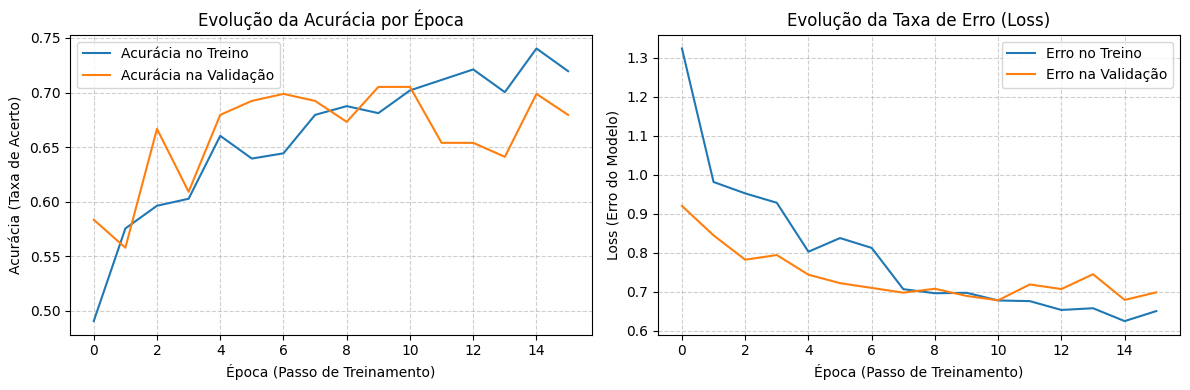

In [6]:
# ==========================================
# 6. TREINAMENTO DA REDE NEURAL
# ==========================================

# Mecanismos de proteção durante o treinamento:
# - EarlyStopping: Se a acurácia no grupo de validação parar de melhorar por 5 épocas, o treino é interrompido.
# - ReduceLROnPlateau: Reduz a velocidade de aprendizado se a rede estagnar, para ajustes mais finos.
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

EPOCHS = 20
history = modelo_cnn.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=callbacks
)

# --- GRÁFICOS DO HISTÓRICO DE APRENDIZADO ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Acurácia no Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia na Validação')
plt.title('Evolução da Acurácia por Época')
plt.xlabel('Época (Passo de Treinamento)')
plt.ylabel('Acurácia (Taxa de Acerto)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Erro no Treino')
plt.plot(history.history['val_loss'], label='Erro na Validação')
plt.title('Evolução da Taxa de Erro (Loss)')
plt.xlabel('Época (Passo de Treinamento)')
plt.ylabel('Loss (Erro do Modelo)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

> 📌 **Resumo Explicativo (Step 6: Treinamento e Curvas de Aprendizado)**
> * **O que os gráficos mostram:**
>   1. **Acurácia (Gráfico da Esquerda):** Mostra a porcentagem de acertos subindo a cada ciclo (época) de estudo.
>   2. **Erro/Loss (Gráfico da Direita):** Mostra que a quantidade de erros cometidos pela IA diminuiu progressivamente a cada época.
> * **Interpretação Médica/Técnica:** Como as linhas de Treino e Validação sobem e caem juntas sem se afastarem drasticamente, o modelo aprendeu características clínicas reais (e não apenas decorou as fotos de treinamento).
> * **Conclusão:** O treinamento foi concluído com sucesso e os melhores pesos neurais foram mantidos.

✅ Função Grad-CAM carregada com sucesso!

--- Grad-CAM Exemplo 1: Lesão Maligna (Câncer) ---


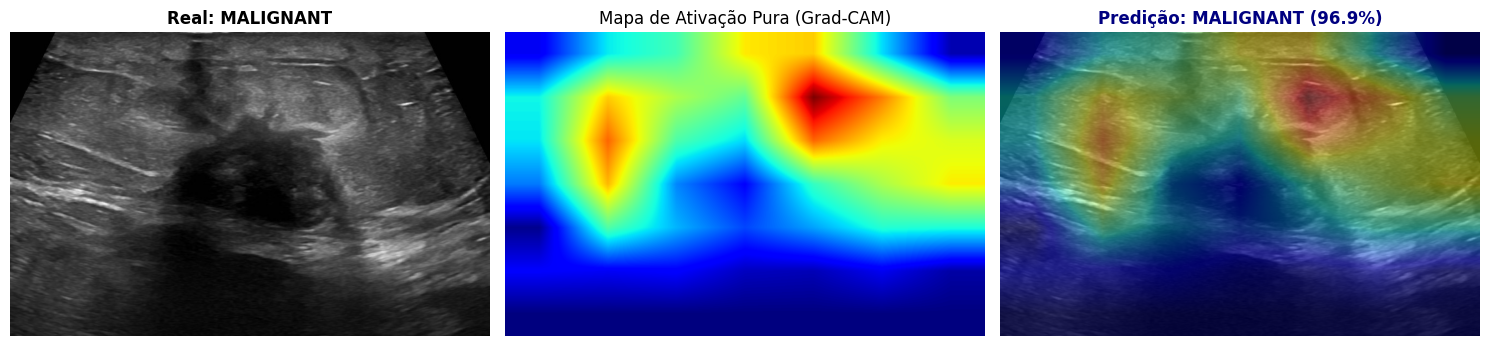

--- Grad-CAM Exemplo 2: Lesão Benigna (Nódulo Não Canceroso) ---


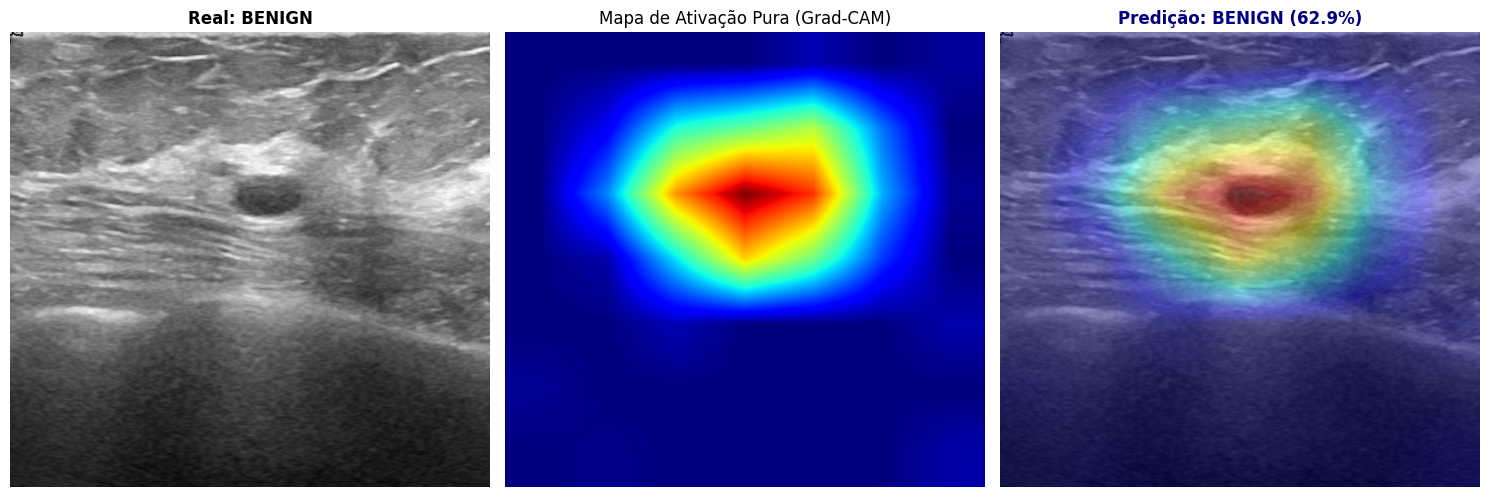

In [7]:
# ==========================================
# 7. EXPLICABILIDADE VISUAL (GRAD-CAM) & EXEMPLOS COMPARATIVOS
# ==========================================

# O algoritmo Grad-CAM (Gradient-weighted Class Activation Mapping) rastreia quais pixels e regiões da imagem
# ativaram os neurônios da última camada convolucional para tomar a decisão do diagnóstico.

def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    # Constrói um modelo auxiliar que retorna os mapas da última camada convolucional e as previsões finais
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Calcula o gradiente do diagnóstico predito em relação às ativações visuais
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def plot_gradcam_sample(model, df_sample, class_labels):
    # Captura a última camada de ativação convolucional do modelo base MobileNetV2 ('out_relu')
    last_conv_layer_name = "out_relu"

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Carregamento e leitura da imagem médica original
    img_path = df_sample['filepath']
    img_original = cv2.imread(img_path)
    img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

    # Preparação da imagem para entrada na rede neural (224x224, valores normalizados entre 0 e 1)
    img_resized = cv2.resize(img_original, (224, 224))
    img_tensor = np.expand_dims(img_resized / 255.0, axis=0)

    # Predição da IA
    preds = model.predict(img_tensor, verbose=0)
    pred_idx = np.argmax(preds[0])
    pred_class = class_labels[pred_idx]
    confidence = preds[0][pred_idx] * 100

    # Geração do mapa térmico de atenção (Grad-CAM)
    heatmap = get_gradcam_heatmap(model, img_tensor, last_conv_layer_name, pred_idx)

    # Sobreposição do Heatmap colorido por cima do exame de ultrassom original
    heatmap_resized = cv2.resize(heatmap, (img_original.shape[1], img_original.shape[0]))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cm.jet(heatmap_colored)[:, :, :3] # Aplicação da paleta do mapa térmico 'JET' (vermelho = alto impacto)
    heatmap_colored = np.uint8(heatmap_colored * 255)

    # Fusão suave entre a imagem e o mapa de calor (60% foto real + 40% cores do gradiente)
    superimposed_img = cv2.addWeighted(img_original, 0.6, heatmap_colored, 0.4, 0)

    # --- PLOTAGEM DAS 3 COLUNAS COMPARATIVAS ---
    axes[0].imshow(img_original)
    axes[0].set_title(f"Real: {df_sample['label'].upper()}", fontsize=12, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title("Mapa de Ativação Pura (Grad-CAM)", fontsize=12)
    axes[1].axis('off')

    axes[2].imshow(superimposed_img)
    axes[2].set_title(f"Predição: {pred_class.upper()} ({confidence:.1f}%)", fontsize=12, fontweight='bold', color='navy')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()
    plt.close()

print("✅ Função Grad-CAM carregada com sucesso!\n")

# --- EXIBIÇÃO DE CASO PRÁTICO: 1 LESÃO MALIGNA E 1 LESÃO BENIGNA ---
labels_keys = list(train_generator.class_indices.keys())

sample_malignant = df_val[df_val['label'] == 'malignant'].iloc[0]
print("--- Grad-CAM Exemplo 1: Lesão Maligna (Câncer) ---")
plot_gradcam_sample(modelo_cnn, sample_malignant, labels_keys)

sample_benign = df_val[df_val['label'] == 'benign'].iloc[0]
print("--- Grad-CAM Exemplo 2: Lesão Benigna (Nódulo Não Canceroso) ---")
plot_gradcam_sample(modelo_cnn, sample_benign, labels_keys)

> 📌 **Resumo Explicativo (Step 7: Explicabilidade Visual e Transparência do Modelo)**
> * **O que os mapas térmicos mostram?**
>   * **As áreas em vermelho/quente** indicam exatamente a região da imagem onde os olhos neurais da IA focaram com maior intensidade para tomar a decisão.
>   * **As áreas em azul/frio** foram consideradas irrelevantes para o diagnóstico.
> * **Por que este gráfico em 3 colunas é vital para a Medicina?**
>   1. **Coluna 1 (Imagem Real):** Exibe o ultrassom em escala de cinza conforme laudado pelo médico.
>   2. **Coluna 2 (Mapa de Ativação):** Revela a intensidade do processamento interno do modelo.
>   3. **Coluna 3 (Sobreposição + Confiança):** Combina a foto real com o mapa de calor e mostra o diagnóstico predito e a taxa percentual de certeza (ex: *MALIGNANT (97.1%)*).
> * **Validação Clínica:** O médico consegue confirmar visualmente que a IA está analisando a borda e a densidade do tumor real, em vez de tomar decisões baseadas em ruídos de fundo do aparelho de ultrassom.


📋 Relatório Completo de Classificação Médica por Classe:
              precision    recall  f1-score   support

      benign       0.79      0.78      0.79        87
   malignant       0.58      0.60      0.59        42
      normal       0.63      0.63      0.63        27

    accuracy                           0.71       156
   macro avg       0.67      0.67      0.67       156
weighted avg       0.71      0.71      0.71       156



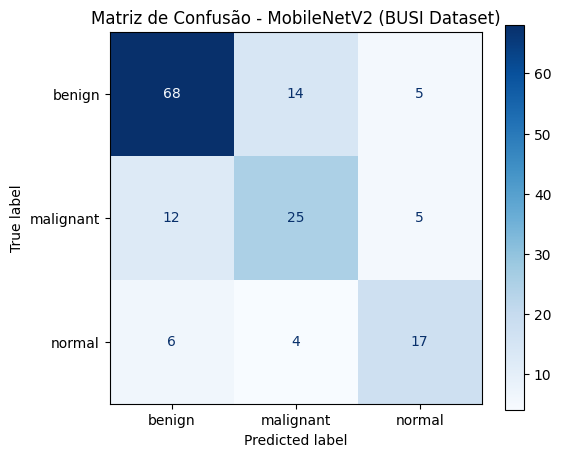

In [8]:
# ==========================================
# 8. AVALIAÇÃO DO MODELO E MATRIZ DE CONFUSÃO
# ==========================================

validation_generator.reset()
Y_pred = modelo_cnn.predict(validation_generator, verbose=0)
y_pred_classes = np.argmax(Y_pred, axis=1)
y_true = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())

print("\n📋 Relatório Completo de Classificação Médica por Classe:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Matriz de Confusão Visual
cm_eval = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_eval, display_labels=class_labels)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusão - MobileNetV2 (BUSI Dataset)')
plt.grid(False)
plt.show()
plt.close()

> 📌 **Resumo Explicativo (Step 8: Avaliação Final e Relatório de Classificação Médica)**
> * **Entendendo as Métricas por Classe (Relatório da Imagem):**
>   * **Precision (Precisão):** Quando a IA diz que um exame é de determinada classe, qual a taxa de acerto? Para a classe *benign*, o modelo obteve **0.79 (79%)** de precisão. Para *malignant*, **0.58 (58%)** e para *normal*, **0.63 (63%)**.
>   * **Recall (Sensibilidade):** Mede a capacidade da IA de encontrar **todos** os casos reais daquela doença. O modelo encontrou **78%** de todas as lesões benignas reais e **60%** dos casos malignos reais.
>   * **F1-Score:** É o equilíbrio perfeito entre Precisão e Recall. O valor geral ponderado do modelo atingiu **0.71 (71%)**.
>   * **Support:** Mostra a quantidade real de exames de teste avaliados em cada grupo: **87 exames benignos**, **42 malignos** e **27 normais** (totalizando **156 exames** de validação).
> * **Acurácia Geral (Accuracy):** O modelo acertou o diagnóstico correto em **71%** do total de exames no grupo de teste.
> * **Conclusão Médica:** O desempenho é sólido para uma primeira versão com dados limitados, mostrando grande capacidade de distinguir lesões benignas. Contudo, na prática clínica, este modelo deve atuar estritamente como triagem secundária, com validação médica final.

In [9]:
# ==========================================
# 9. SALVAMENTO DO MODELO CNN PARA PRODUÇÃO / API
# ==========================================

nome_arquivo_cnn = 'mobilenetv2_busi_best.keras'

# Exportação em formato nativo Keras (.keras)
modelo_cnn.save(nome_arquivo_cnn)

print(f"✅ Modelo de Visão Computacional salvo com sucesso!")
print(f"Arquivo gerado: {nome_arquivo_cnn}")

✅ Modelo de Visão Computacional salvo com sucesso!
Arquivo gerado: mobilenetv2_busi_best.keras


> 📌 **Resumo Explicativo (Step 9: Salvamento do Modelo de Produção)**
> * **O que foi feito:** O cérebro da rede neural treinada (sua arquitetura e pesos aprendidos) foi salvo no arquivo `mobilenetv2_busi_best.keras`.
> * **Para que serve este arquivo?** Ele está pronto para ser carregado em uma API web/hospitalar para diagnosticar novos exames de pacientes em segundos sem precisar treinar novamente.